### build a model to classify the function different regions

In [1]:
from chrombert_tools import region_function_classification

In [2]:
help(region_function_classification)

Help on function region_function_classification in module chrombert_tools.api.region_function_classification:

region_function_classification(function_beds: 'Optional[Union[str, Sequence[str]]]' = None, function_modes: 'Optional[Sequence[str]]' = None, function_names: 'Optional[Sequence[str]]' = None, predict_file: 'Optional[str]' = None, ignore_regulator: 'Optional[str]' = None, odir: 'str' = './output', genome: 'str' = 'hg38', resolution: 'str' = '1kb', ft_ckpt: 'Optional[str]' = None, batch_size: 'int' = 4, mode: 'str' = 'fast', chrombert_cache_dir: 'Optional[str]' = None, chrombert_region_file: 'Optional[str]' = None, chrombert_region_emb_file: 'Optional[str]' = None, chrombert_regulator_file: 'Optional[str]' = None, hdf5_file: 'Optional[str]' = None, pretrain_ckpt: 'Optional[str]' = None, mtx_mask: 'Optional[str]' = None, meta_file: 'Optional[str]' = None) -> 'ChrombertPredictionRunResult'
    Train or load a ChromBERT functional classifier and run prediction (same pipeline
    as

In [5]:
### build a model to classify the function different regions
    # group1: ezh2 and h3k27me3 co-binding region
    # group2: ezh2 binding region without h3k27me3

results = region_function_classification(
    function_beds=["../data/hESC_GSM1003524_EZH2.bed;../data/hESC_GSM1498900_H3K27me3.bed","../data/hESC_GSM1003524_EZH2.bed"], # your focus region groups
    function_names=["ezh2_h3k27me3","ezh2"], # the names of the region groups
    odir="./output_region_function_classification",
    ignore_regulator="H3K27me3;H3K27me3/H3K4me3", # the regulators to ignore, because these regulator are already to identify this regions, so we want to ignore them and to find the other important regulators
    genome="hg38",
    resolution="1kb"
)

Note: All regulator names were converted to lowercase for matching.
Regulator count summary - requested: 2, matched in ChromBERT: 2, not found: 0, not found regulator: []
ChromBERT regulators: /mnt/Storage/home/chenqianqian/.cache/chrombert/data/config/hg38_6k_regulators_list.txt
Stage 1: Preparing dataset
[ezh2_h3k27me3 | hESC_GSM1003524_EZH2.bed] Region summary - total: 11896, overlapping with ChromBERT: 12101 (one region may overlap multiple ChromBERT regions, we keep overlaps with ≥50% coverage of either the ChromBERT bin or the input region), non-overlapping: 325
[ezh2_h3k27me3 | hESC_GSM1498900_H3K27me3.bed] Region summary - total: 8875, overlapping with ChromBERT: 14135 (one region may overlap multiple ChromBERT regions, we keep overlaps with ≥50% coverage of either the ChromBERT bin or the input region), non-overlapping: 2878
  ezh2_h3k27me3 (class 0): 5736 regions
[ezh2] Region summary - total: 11896, overlapping with ChromBERT: 12101 (one region may overlap multiple ChromBERT

/mnt/Storage2/home/chenqianqian/projects/chrombert/chrombert_tools/ChromBERT-tools/chrombert_tools/cli/utils_classfication.py:149: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  combined.groupby("label", group_keys=False)


Load pretrained ckpt /mnt/Storage/home/chenqianqian/.cache/chrombert/data/checkpoint/hg38_6k_1kb_pretrain.ckpt successfully!


Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
Loading `train_dataloader` to estimate number of stepping batches.
/mnt/Storage/home/chenqianqian/miniconda3/envs/chrombert/lib/python3.9/site-pack

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric default_validation/auprc did not improve in the last 5 records. Best score: 0.906. Signaling Trainer to stop.


Evaluating the finetuned model performance
Load pretrained ckpt /mnt/Storage/home/chenqianqian/.cache/chrombert/data/checkpoint/hg38_6k_1kb_pretrain.ckpt successfully!
Loading checkpoint from /mnt/Storage2/home/chenqianqian/projects/chrombert/chrombert_tools/ChromBERT-tools/examples/api/output_region_function_classification/train/try_00_seed_55/lightning_logs/lightning_logs/version_0/checkpoints/epoch=2-step=90.ckpt
Loading from pl module, remove prefix 'model.'
Loading from pl module, replace 'pretrain_model' with 'pretrain_model.chrombert'
Loaded 111/111 parameters
ft_ckpt: /mnt/Storage2/home/chenqianqian/projects/chrombert/chrombert_tools/ChromBERT-tools/examples/api/output_region_function_classification/train/try_00_seed_55/lightning_logs/lightning_logs/version_0/checkpoints/epoch=2-step=90.ckpt, test_metrics: {'auroc': 0.88494473695755, 'auprc': 0.8885455131530762, 'mcc': 0.5954238772392273, 'f1': 0.7598719596862793, 'precision': 0.8496419787406921, 'recall': 0.6872586607933044}
A

Predicting: 100%|██████████| 276/276 [00:54<00:00,  5.05it/s]

  Predictions saved: /mnt/Storage2/home/chenqianqian/projects/chrombert/chrombert_tools/ChromBERT-tools/examples/api/output_region_function_classification/predict/predictions.csv  (1101 regions)
Finished stage 3

All stages completed!
Fine-tuned model saved in: ./output_region_function_classification/train/try_00_seed_55
Classes (2): ezh2_h3k27me3, ezh2
Predictions: ./output_region_function_classification/predict/predictions.csv
Fine-tuned checkpoint: /mnt/Storage2/home/chenqianqian/projects/chrombert/chrombert_tools/ChromBERT-tools/examples/api/output_region_function_classification/train/try_00_seed_55/lightning_logs/lightning_logs/version_0/checkpoints/epoch=2-step=90.ckpt
Predictions: ./output_region_function_classification/predict/predictions.csv


In [10]:
results.__dataclass_fields__

{'model': Field(name='model',type='Any',default=<dataclasses._MISSING_TYPE object at 0x7f8caaff4550>,default_factory=<dataclasses._MISSING_TYPE object at 0x7f8caaff4550>,init=True,repr=True,hash=None,compare=True,metadata=mappingproxy({}),_field_type=_FIELD),
 'model_config': Field(name='model_config',type='Any',default=<dataclasses._MISSING_TYPE object at 0x7f8caaff4550>,default_factory=<dataclasses._MISSING_TYPE object at 0x7f8caaff4550>,init=True,repr=True,hash=None,compare=True,metadata=mappingproxy({}),_field_type=_FIELD),
 'data_config': Field(name='data_config',type='Any',default=<dataclasses._MISSING_TYPE object at 0x7f8caaff4550>,default_factory=<dataclasses._MISSING_TYPE object at 0x7f8caaff4550>,init=True,repr=True,hash=None,compare=True,metadata=mappingproxy({}),_field_type=_FIELD),
 'predictions_df': Field(name='predictions_df',type='pd.DataFrame',default=<dataclasses._MISSING_TYPE object at 0x7f8caaff4550>,default_factory=<dataclasses._MISSING_TYPE object at 0x7f8caaff455

In [11]:
results.model_ckpt

'/mnt/Storage2/home/chenqianqian/projects/chrombert/chrombert_tools/ChromBERT-tools/examples/api/output_region_function_classification/train/try_00_seed_55/lightning_logs/lightning_logs/version_0/checkpoints/epoch=2-step=90.ckpt'

In [15]:
results.predictions_df ### these predicted_label by threshold 0.5, you can change the threshold to get the different results

,chrom,start,end,build_region_index,true_label,prob_ezh2_h3k27me3,predicted_label,predicted_name
0,chr1,960000,961000,255,0,0.589054,1,ezh2
1,chr1,1274000,1275000,553,1,0.179563,0,ezh2_h3k27me3
2,chr1,3072000,3073000,2128,0,0.193262,0,ezh2_h3k27me3
3,chr1,3392000,3393000,2425,0,0.566183,1,ezh2
4,chr1,3393000,3394000,2426,0,0.194490,0,ezh2_h3k27me3
...,...,...,...,...,...,...,...,...
1096,chrX,118976000,118977000,2116903,0,0.231761,0,ezh2_h3k27me3
1097,chrX,119999000,120000000,2117687,0,0.514951,1,ezh2
1098,chrX,131073000,131074000,2123007,1,0.426829,0,ezh2_h3k27me3
1099,chrX,134545000,134546000,2125186,1,0.592574,1,ezh2


In [18]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc_score(results.predictions_df.true_label,results.predictions_df.prob_ezh2_h3k27me3),average_precision_score(results.predictions_df.true_label,results.predictions_df.prob_ezh2_h3k27me3)


(0.8849447340013379, 0.8885454977484899)

In [13]:
results.model_config

'./output_region_function_classification/model_config.json'

In [14]:
results.data_config

'./output_region_function_classification/dataset_config.json'

In [19]:
with open(results.model_config,"r") as f:
    print(f.read())

{"genome": "hg38", "task": "general", "dim_output": 1, "pretrained_model_name_or_path": "/mnt/Storage/home/chenqianqian/.cache/chrombert/data/checkpoint/hg38_6k_1kb_pretrain.ckpt", "trust_remote_code": true, "pretrained_model_kwargs": {}, "pretrain_ckpt": "/mnt/Storage/home/chenqianqian/.cache/chrombert/data/checkpoint/hg38_6k_1kb_pretrain.ckpt", "mtx_mask": "/mnt/Storage/home/chenqianqian/.cache/chrombert/data/config/hg38_6k_mask_matrix.tsv", "dropout": 0, "finetune_ckpt": "/mnt/Storage2/home/chenqianqian/projects/chrombert/chrombert_tools/ChromBERT-tools/examples/api/output_region_function_classification/train/try_00_seed_55/lightning_logs/lightning_logs/version_0/checkpoints/epoch=2-step=90.ckpt", "ignore": true, "ignore_index": [[972, 518, 1296, 1065, 730, 931, 806, 2601, 1376, 559, 1019, 1760, 1041, 1152, 1787, 2313, 1792, 745, 749, 1026, 2599, 2815, 938, 2707, 750, 2299, 571, 669, 798, 1070, 2962, 499, 2731, 2899, 2981, 2741, 1371, 2435, 1036, 904, 889, 751, 1052, 1902, 2157, 243

In [21]:
with open(results.data_config,"r") as f:
    print(f.read())

{
    "hdf5_file": "/mnt/Storage/home/chenqianqian/.cache/chrombert/data/hg38_6k_1kb.hdf5",
    "supervised_file": "./output_region_function_classification/predict/model_input.tsv",
    "kind": "GeneralDataset",
    "meta_file": "/mnt/Storage/home/chenqianqian/.cache/chrombert/data/config/hg38_6k_meta.json",
    "ignore": true,
    "ignore_object": "h3k27me3;h3k27me3/h3k4me3",
    "batch_size": 4,
    "num_workers": 8,
    "shuffle": false,
    "pin_memory": true,
    "perturbation": false,
    "perturbation_object": null,
    "perturbation_value": 0,
    "prompt_kind": null,
    "prompt_regulator": null,
    "prompt_regulator_cache_file": null,
    "prompt_celltype": null,
    "prompt_celltype_cache_file": null,
    "prompt_regulator_cache_pin_memory": false,
    "prompt_regulator_cache_limit": 3,
    "fasta_file": null,
    "flank_window": 0
}


In [20]:
results.model_ckpt

'/mnt/Storage2/home/chenqianqian/projects/chrombert/chrombert_tools/ChromBERT-tools/examples/api/output_region_function_classification/train/try_00_seed_55/lightning_logs/lightning_logs/version_0/checkpoints/epoch=2-step=90.ckpt'

### identify the important factor for the different regions

In [ ]:
ft_ckpt = results.model_ckpt
# ft_ckpt = '/mnt/Storage2/home/chenqianqian/projects/chrombert/chrombert_tools/ChromBERT-tools/examples/api/output_region_function_classification/train/try_00_seed_55/lightning_logs/lightning_logs/version_0/checkpoints/epoch=2-step=90.ckpt'
ft_ckpt

'/mnt/Storage2/home/chenqianqian/projects/chrombert/chrombert_tools/ChromBERT-tools/examples/api/output_region_function_classification/train/try_00_seed_55/lightning_logs/lightning_logs/version_0/checkpoints/epoch=2-step=90.ckpt'

In [4]:
from chrombert_tools import interpret_regulator_effects_between_region_groups as run_key_regulator

In [5]:
import pandas as pd
test_data = pd.read_csv("./output_region_function_classification/dataset/test_sampled.csv")
odir="interpretation_important_factor_effect_ezh2"
!mkdir -p "interpretation_important_factor_effect_ezh2"

In [6]:
ezh2_k27me3_region_sample_file = f"{odir}/ezh2_h3k27me3_region_sample.csv"
ezh2_only_region_sample_file = f"{odir}/ezh2_only_region_sample.csv"
test_data.query("label==0").to_csv(ezh2_k27me3_region_sample_file,index=False)
test_data.query("label==1").to_csv(ezh2_only_region_sample_file,index=False)

In [ ]:
factor_importance_rank = run_key_regulator(
    region1_file=ezh2_k27me3_region_sample_file, # your focus region group 1
    region2_file=ezh2_only_region_sample_file, # your focus region group 2
    odir=odir, # output directory
    genome="hg38", # genome
    resolution="1kb", # resolution
    ft_ckpt=ft_ckpt,
    batch_size=64, # batch size
    # model_config='./output_region_function_classification/model_config.json',
    # data_config='./output_region_function_classification/dataset_config.json',
    model_config=results.model_config,
    data_config=results.data_config,
)

Region summary - total: 583, overlapping with ChromBERT: 583 (one region may overlap multiple ChromBERT regions, we keep overlaps with ≥50% coverage of either the ChromBERT bin or the input region), non-overlapping: 0
Region summary - total: 518, overlapping with ChromBERT: 518 (one region may overlap multiple ChromBERT regions, we keep overlaps with ≥50% coverage of either the ChromBERT bin or the input region), non-overlapping: 0
Load pretrained ckpt /mnt/Storage/home/chenqianqian/.cache/chrombert/data/checkpoint/hg38_6k_1kb_pretrain.ckpt successfully!
Loading checkpoint from /mnt/Storage2/home/chenqianqian/projects/chrombert/chrombert_tools/ChromBERT-tools/examples/api/output_region_function_classification/train/try_00_seed_55/lightning_logs/lightning_logs/version_0/checkpoints/epoch=2-step=90.ckpt
Loading from pl module, remove prefix 'model.'
Loading from pl module, replace 'pretrain_model' with 'pretrain_model.chrombert'
Loaded 111/111 parameters


100%|██████████| 130/130 [00:09<00:00, 13.25it/s]


Identify key regulators across regions(top 25)
      factors  similarity  rank  embedding_shift
0       suz12    0.828531     1         0.171469
1       dnase    0.841583     2         0.158417
2        ezh2    0.871878     3         0.128122
3        ctcf    0.889448     4         0.110552
4       ssu72    0.890448     5         0.109552
5      supt5h    0.892739     6         0.107261
6       fgfr1    0.894543     7         0.105457
7        cbx3    0.894630     8         0.105370
8         sp4    0.895236     9         0.104764
9         tbp    0.896751    10         0.103249
10       ezh1    0.896976    11         0.103024
11       chd8    0.897261    12         0.102739
12       taf7    0.897315    13         0.102685
13    h3k4me3    0.897389    14         0.102611
14      ep300    0.898191    15         0.101809
15    h3k27ac    0.899479    16         0.100521
16       taf1    0.899601    17         0.100399
17   atac-seq    0.899675    18         0.100325
18     polr2a    0.899

In [8]:
factor_importance_rank.head(n=25)

,factors,similarity,rank,embedding_shift
0,suz12,0.828531,1,0.171469
1,dnase,0.841583,2,0.158417
2,ezh2,0.871878,3,0.128122
3,ctcf,0.889448,4,0.110552
4,ssu72,0.890448,5,0.109552
5,supt5h,0.892739,6,0.107261
6,fgfr1,0.894543,7,0.105457
7,cbx3,0.894630,8,0.105370
8,sp4,0.895236,9,0.104764
9,tbp,0.896751,10,0.103249


### identify the important cofactors of EZH2 for the different regions

In [9]:
from chrombert_tools import interpret_regulator_regulator_interactions

Region summary - total: 583, overlapping with ChromBERT: 583 (one region may overlap multiple ChromBERT regions, we keep overlaps with ≥50% coverage of either the ChromBERT bin or the input region), non-overlapping: 0
Note: All regulator names were converted to lowercase for matching.
Regulator count summary - requested: 1, matched in ChromBERT: 1, not found: 0, not found regulator: []
ChromBERT regulators: /mnt/Storage/home/chenqianqian/.cache/chrombert/data/config/hg38_6k_regulators_list.txt
Load pretrained ckpt /mnt/Storage/home/chenqianqian/.cache/chrombert/data/checkpoint/hg38_6k_1kb_pretrain.ckpt successfully!
Loading checkpoint from /mnt/Storage2/home/chenqianqian/projects/chrombert/chrombert_tools/ChromBERT-tools/examples/api/output_region_function_classification/train/try_00_seed_55/lightning_logs/lightning_logs/version_0/checkpoints/epoch=2-step=90.ckpt
Loading from pl module, remove prefix 'model.'
Loading from pl module, replace 'pretrain_model' with 'pretrain_model.chrombe

100%|██████████| 146/146 [00:20<00:00,  7.23it/s]


Total graph nodes: 1015
Total graph edges (threshold=0.625): 28650
Regulator subnetwork saved to: ./output_regulator_network_ezh2_1/subnetwork_ezh2_k1_q0.950_thr0.625.pdf
Finished!
Saved outputs to: ./output_regulator_network_ezh2_1
Regulator cosine similarity saved to: ./output_regulator_network_ezh2_1/regulator_cosine_similarity.tsv
Total graph edges saved to: ./output_regulator_network_ezh2_1/total_graph_edge_threshold0.625_quantile0.950.tsv


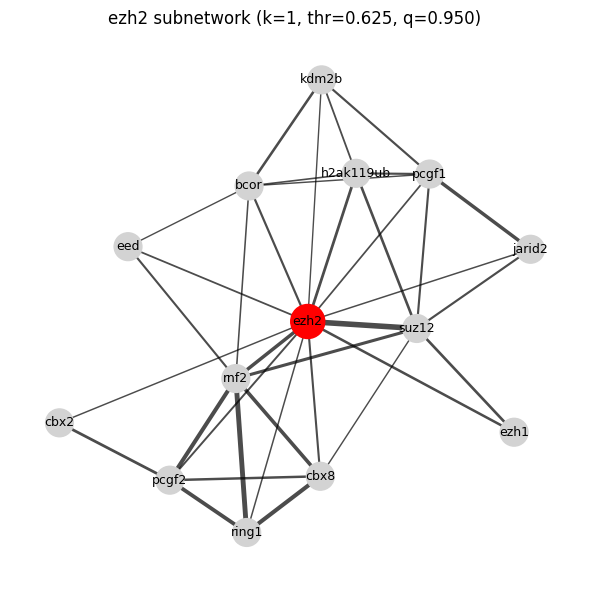

In [11]:
df_cos_sim_1, df_edges_1 = interpret_regulator_regulator_interactions(
    region=ezh2_k27me3_region_sample_file,
    regulator="ezh2",      # Plot subnetworks for these regulators
    odir="./output_regulator_network_ezh2_1",
    ft_ckpt=ft_ckpt,
    genome="hg38",                      # Options: "hg38", "mm10"
    resolution="1kb",                   # Options: "1kb", "2kb", "4kb", "200bp"
    quantile=0.95,
    # model_config='./output_region_function_classification/model_config.json',
    # data_config='./output_region_function_classification/dataset_config.json',
    model_config=results.model_config,
    data_config=results.data_config,
)

Region summary - total: 518, overlapping with ChromBERT: 518 (one region may overlap multiple ChromBERT regions, we keep overlaps with ≥50% coverage of either the ChromBERT bin or the input region), non-overlapping: 0
Note: All regulator names were converted to lowercase for matching.
Regulator count summary - requested: 1, matched in ChromBERT: 1, not found: 0, not found regulator: []
ChromBERT regulators: /mnt/Storage/home/chenqianqian/.cache/chrombert/data/config/hg38_6k_regulators_list.txt
Load pretrained ckpt /mnt/Storage/home/chenqianqian/.cache/chrombert/data/checkpoint/hg38_6k_1kb_pretrain.ckpt successfully!
Loading checkpoint from /mnt/Storage2/home/chenqianqian/projects/chrombert/chrombert_tools/ChromBERT-tools/examples/api/output_region_function_classification/train/try_00_seed_55/lightning_logs/lightning_logs/version_0/checkpoints/epoch=2-step=90.ckpt
Loading from pl module, remove prefix 'model.'
Loading from pl module, replace 'pretrain_model' with 'pretrain_model.chrombe

100%|██████████| 130/130 [00:20<00:00,  6.32it/s]


Total graph nodes: 1033
Total graph edges (threshold=0.566): 28650
Regulator subnetwork saved to: ./output_regulator_network_ezh2_2/subnetwork_ezh2_k1_q0.950_thr0.566.pdf
Finished!
Saved outputs to: ./output_regulator_network_ezh2_2
Regulator cosine similarity saved to: ./output_regulator_network_ezh2_2/regulator_cosine_similarity.tsv
Total graph edges saved to: ./output_regulator_network_ezh2_2/total_graph_edge_threshold0.566_quantile0.950.tsv


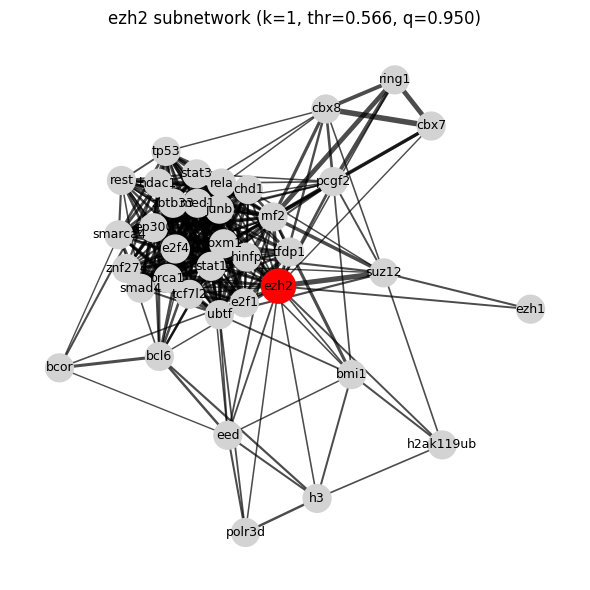

In [12]:
df_cos_sim_2, df_edges_2 = interpret_regulator_regulator_interactions(
    region=ezh2_only_region_sample_file,
    regulator="ezh2",      # Plot subnetworks for these regulators
    odir="./output_regulator_network_ezh2_2",
    ft_ckpt=ft_ckpt,
    genome="hg38",                      # Options: "hg38", "mm10"
    resolution="1kb",                   # Options: "1kb", "2kb", "4kb", "200bp"
    quantile=0.95,
    # model_config='./output_region_function_classification/model_config.json',
    # data_config='./output_region_function_classification/dataset_config.json',
    model_config=results.model_config,
    data_config=results.data_config,
)

In [15]:
df_edges_2_ezh2 = df_edges_2.query("node1=='ezh2'")
df_edges_1_ezh2 = df_edges_1.query("node1=='ezh2'")

In [20]:
merge_df = pd.merge(df_edges_1_ezh2, df_edges_2_ezh2, on="node2", how="outer",suffixes=("_ezh2_1", "_ezh2_2"))
merge_df.query("node1_ezh2_1 != node1_ezh2_1") # specific cofactor on function region2

,node1_ezh2_1,node2,cosine_similarity_ezh2_1,node1_ezh2_2,cosine_similarity_ezh2_2
0,NaN,foxm1,NaN,ezh2,0.621829
2,NaN,h3,NaN,ezh2,0.581819
3,NaN,hdac1,NaN,ezh2,0.577564
4,NaN,hinfp,NaN,ezh2,0.601859
6,NaN,junb,NaN,ezh2,0.571182
8,NaN,med1,NaN,ezh2,0.582780
11,NaN,polr3d,NaN,ezh2,0.578753
12,NaN,rela,NaN,ezh2,0.589152
13,NaN,rest,NaN,ezh2,0.584213
16,NaN,smad4,NaN,ezh2,0.570978


In [21]:
merge_df.query("node1_ezh2_2 != node1_ezh2_2") # specific cofactor on function region1

,node1_ezh2_1,node2,cosine_similarity_ezh2_1,node1_ezh2_2,cosine_similarity_ezh2_2
5,ezh2,jarid2,0.633189,NaN,NaN
7,ezh2,kdm2b,0.625543,NaN,NaN
9,ezh2,pcgf1,0.648713,NaN,NaN


In [23]:
merge_df.query("node1_ezh2_2 == node1_ezh2_2 and node1_ezh2_1 == node1_ezh2_1 and (cosine_similarity_ezh2_1 - cosine_similarity_ezh2_2 > 0.1 or cosine_similarity_ezh2_1 - cosine_similarity_ezh2_2 < -0.1)") # specific cofactor on function region1 and region2

,node1_ezh2_1,node2,cosine_similarity_ezh2_1,node1_ezh2_2,cosine_similarity_ezh2_2
1,ezh2,h2ak119ub,0.717315,ezh2,0.60734


### Or focus on another interpretation of your choice
### See also the other interpretation tutorials (e.g. in `examples/api/`)